In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## ** Data Analysis  python Project - Blinkit Analysis **

In [8]:
from google.colab import files
uploaded = files.upload()

Saving blinkit_data.csv to blinkit_data.csv


In [9]:
df = pd.read_csv("/content/blinkit_data.csv")

In [10]:
df.head(20)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0,NaN,NaN,NaN,NaN,NaN
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0,NaN,NaN,NaN,NaN,NaN
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0,NaN,NaN,NaN,NaN,NaN
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0,NaN,NaN,NaN,NaN,NaN
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0,NaN,NaN,NaN,NaN,NaN
5,Low Fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0,NaN,NaN,NaN,NaN,NaN
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0,NaN,NaN,NaN,NaN,NaN
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0,NaN,NaN,NaN,NaN,NaN
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0,NaN,NaN,NaN,NaN,NaN
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail(15)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8508,Regular,FDU57,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.089121,NaN,149.8708,4.0
8509,Regular,FDU58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.028871,NaN,188.7898,4.0
8510,Regular,FDX46,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.057835,NaN,57.5562,4.0
8511,Regular,FDX57,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.047037,NaN,96.4068,4.0
8512,Regular,FDY33,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.096730,NaN,159.0262,4.0
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0


In [ ]:
df.shape

(8523, 12)

In [ ]:
list(df.columns)

['Item Fat Content',
 'Item Identifier',
 'Item Type',
 'Outlet Establishment Year',
 'Outlet Identifier',
 'Outlet Location Type',
 'Outlet Size',
 'Outlet Type',
 'Item Visibility',
 'Item Weight',
 'Sales',
 'Rating']

In [ ]:
### DATA CLEANING

In [ ]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


In [ ]:
df.dtypes

,0
Item Fat Content,object
Item Identifier,object
Item Type,object
Outlet Establishment Year,int64
Outlet Identifier,object
Outlet Location Type,object
Outlet Size,object
Outlet Type,object
Item Visibility,float64
Item Weight,float64


In [ ]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'low fat':'Low Fat'})

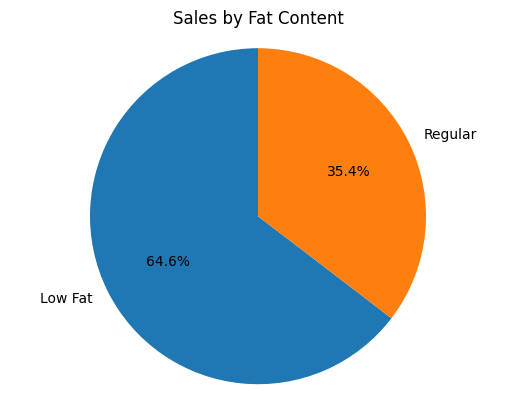

In [ ]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(
    sales_by_fat,
    labels=sales_by_fat.index,
    autopct='%.1f%%',
    startangle=90
)

plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

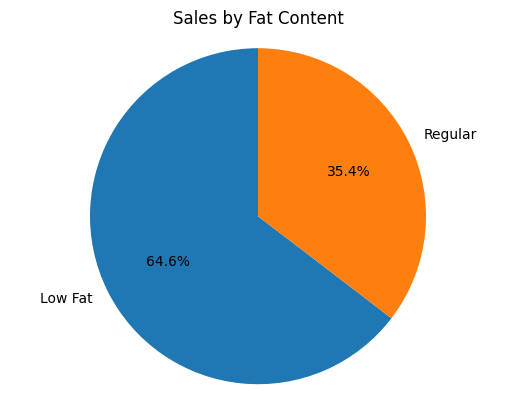

In [ ]:
Sales_by_fat = df.groupby ('Item Fat Content')['Sales'].sum()

plt.pie(
    sales_by_fat,
    labels = sales_by_fat.index,
        autopct = '%.1f%%',
        startangle = 90
)

plt.title('Sales by Fat Content')
plt.axis('equal')
plt.show()

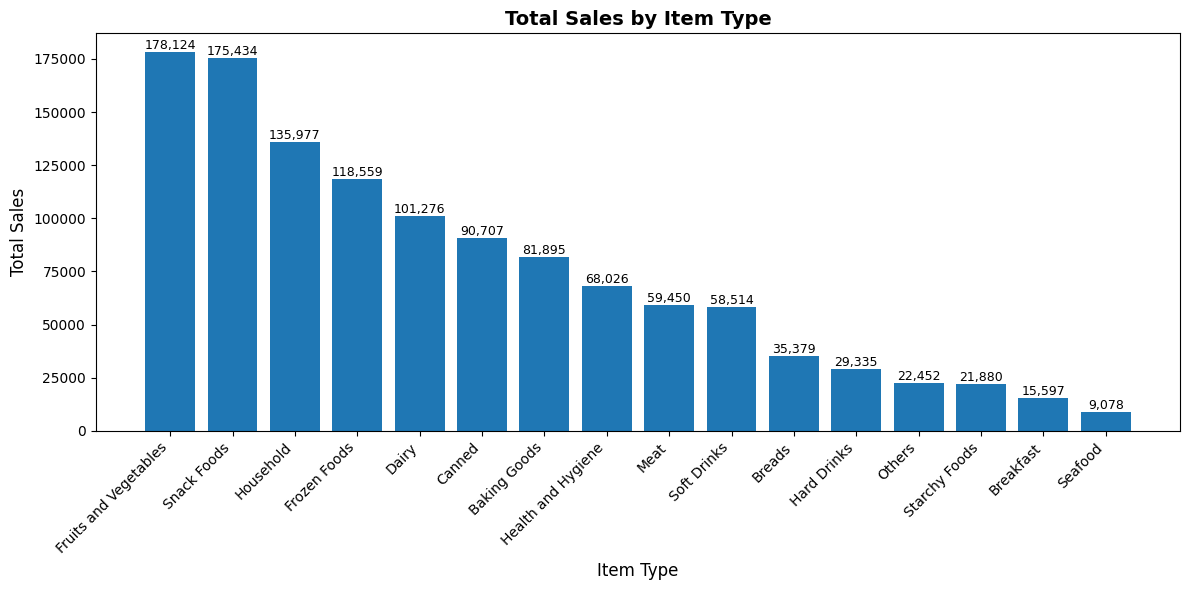

In [ ]:
# Aggregate total sales by item type
sales_by_type = (
    df.groupby("Item Type", as_index=True)["Sales"]
      .sum()
      .sort_values(ascending=False)
)

# Create figure
plt.figure(figsize=(12, 6))

# Plot bar chart
bars = plt.bar(
    x=sales_by_type.index,
    height=sales_by_type.values
)

# Format plot
plt.xticks(rotation=45, ha="right")
plt.xlabel("Item Type", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.title("Total Sales by Item Type", fontsize=14, fontweight="bold")

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

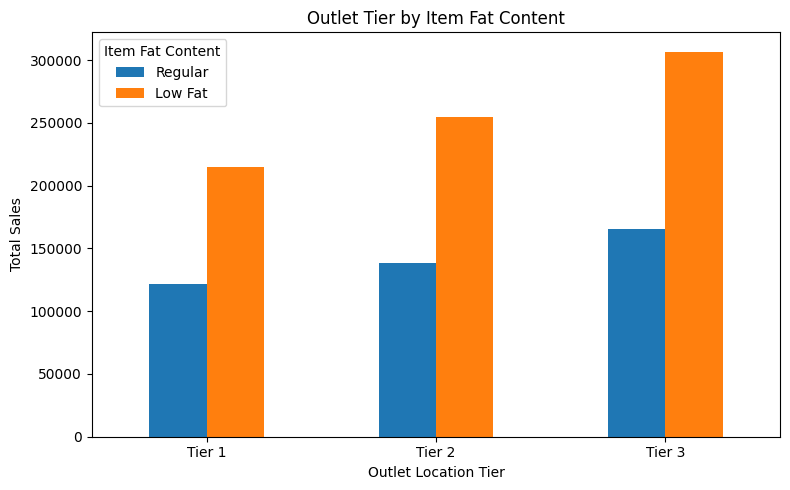

In [ ]:
# Grouping by Outlet and Fat Content, then summing the Sales
grouped = df.groupby(['Outlet Location Type', 'Item Fat Content'])['Sales'].sum().unstack()

# Filtering for specific categories to ensure the plot isn't cluttered
grouped = grouped[['Regular', 'Low Fat']]

ax = grouped.plot(kind='bar', figsize=(8, 5), title='Outlet Tier by Item Fat Content')

# Add labels and formatting
plt.xlabel('Outlet Location Tier')
plt.ylabel('Total Sales')
plt.legend(title='Item Fat Content')

# Optional: Rotates x-axis labels to 0 degrees so they are easier to read
plt.xticks(rotation=0)

# Adjust layout and display
plt.tight_layout()
plt.show()

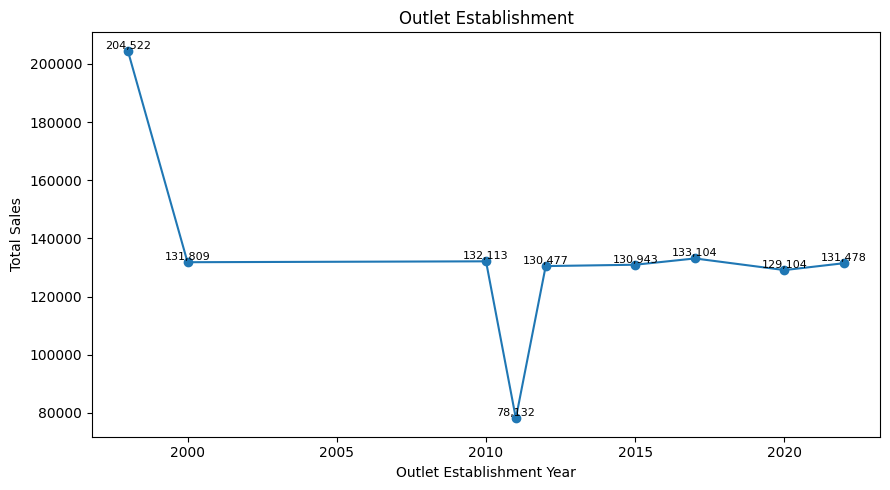

In [ ]:
 #Data Aggregation
sales_by_year = df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()

# Plotting
plt.figure(figsize=(9, 5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle='-')

# Labels and Title
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

# Adding Data Labels
for x, y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

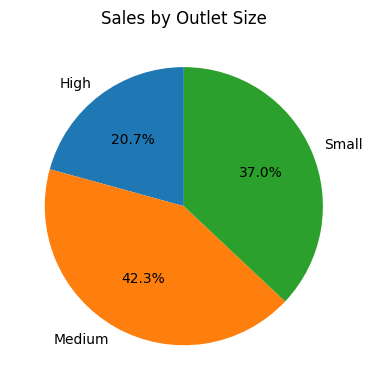

In [ ]:
sales_by_size = df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4, 4))

plt.pie(
    sales_by_size,
    labels=sales_by_size.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Sales by Outlet Size')
plt.tight_layout()
plt.show()

/tmp/ipykernel_165/88247012.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


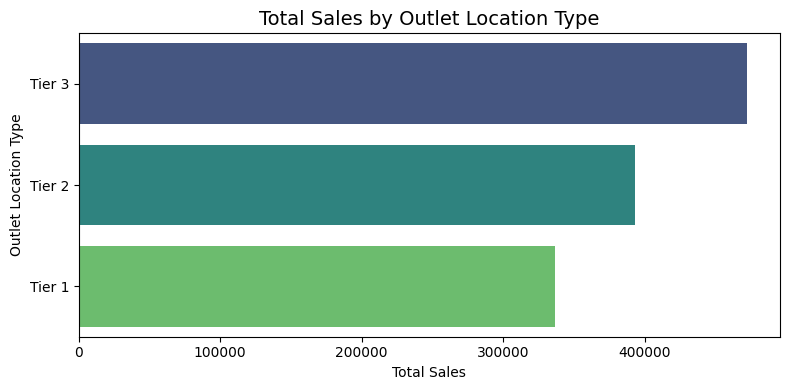

In [ ]:
# Aggregate and sort
sales_by_location = (
    df.groupby('Outlet Location Type', as_index=False)['Sales']
      .sum()
      .sort_values(by='Sales', ascending=False)
)

# Plot
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=sales_by_location,
    x='Sales',
    y='Outlet Location Type',
    palette='viridis'
)

# Improve readability
ax.set_title('Total Sales by Outlet Location Type', fontsize=14)
ax.set_xlabel('Total Sales')
ax.set_ylabel('Outlet Location Type')

plt.tight_layout()
plt.show()